1. Здравствуйте. Хотелось бы немного затронуть вопрос защищенного использования и хранения учетных данных (паролей) в тексте кода. Какие методы чаще применяются.

### Решим техническую задачку.

Представьте себе, что вы работаете в небольшом банке.\
У вас есть данные о клиентах и совершенных ими транзакциях.\
Вам требуется изучить имеющиеся данные, построить отчет заданного вида и визуализацию к нему.

Итак, у вас есть следующие источники данных:
- Справочник клиентов, расположенный в базе данных (таблица clients);
- Транзакции клиентов за несколько дней в виде csv файла (transactions.csv);
- Справочник карт клиентов в формате json (файл cards.json);
- Счета клиентов в виде набора xml файлов (каталог accounts);
- Справочник терминалов, на которых совершались в виде таблицы базы данных (таблица terminals).

Необходимо изучить данные и сформировать отчет вида:
- Дата транзакции
- Адрес терминала, включая индекс
- Геокоординаты терминала
- Совершенная операция
- ФИО Клиента
- Сумма

Требуется учесть только успешно проведенные транзакции. 

После того как отчет собран необходимо построить два графика:
- Линейный график: количество транзакций совершенных в разрезе дней
- Барплот: количество уникальных клиентов в разрезе дней

Каждый из графиков должен быть построен по кажому виду банковских операций

In [ ]:
# 1 работа с транзакциями
import pandas as pd

In [ ]:
df_transactions = pd.read_csv('данные/transactions.csv', sep="|", header=0)

In [ ]:
df_transactions.info()

In [ ]:
df_transactions["transaction_date"] = df_transactions["transaction_date"].astype("datetime64[ns]").dt.date

In [ ]:
df_transactions = df_transactions[df_transactions["oper_result"]=='SUCCESS'].drop(['oper_result'], axis=1)

In [ ]:
df_transactions

In [ ]:
# 2 работаем с терминалами
import psycopg2

conn = psycopg2.connect(database = "postgres",
                        host =     "localhost",
                        user =     "postgres",
                        password = "postgres",
                        port =     "5432")
conn.autocommit = False
cursor = conn.cursor()
cursor.execute("select terminal_id, terminal_address from terminals")
records = cursor.fetchall()
names = [ x[0] for x in cursor.description ]
cursor.close()
conn.close()

df_terminals = pd.DataFrame(records, columns=names)


In [ ]:
df_terminals['postal_code'] = '000000'
df_terminals['geocode'] = '00.0000, 00.0000'

In [ ]:
df_terminals

In [ ]:
# обогащение данных через API
import requests
import json

BASE_URL='https://cleaner.dadata.ru/api/v1/clean/address'
API_KEY = '9f45b36539cb6eacbd15bae105c9cd878cae9ebd'
SECRET = 'b2907d08e0b9878bb1732c9a21860e6b9dca3912'

headers = {
        'Content-Type': 'application/json',
        'Authorization': f'Token {API_KEY}',
        'X-Secret': SECRET
    }

def get_data(query):
    data = [ query ]

    response = requests.post(
        url=BASE_URL,
        headers= headers,
        data=json.dumps(data)
        )
    
    return response

for i, row in enumerate(df_terminals.values.tolist()):
    if i > 1: break
    str_terminal_code = row[0]
    str_address = row[1]
    res = get_data(str_address).json()[0]

    df_terminals.loc[(df_terminals["terminal_id"]==str_terminal_code), ["postal_code", "geocode"]] = \
        [ res.get("postal_code"), res.get("geo_lat") + ', ' + res.get("geo_lon")]    


In [ ]:
df_terminals

In [ ]:
# 3 извлекаем карты клиента

df_cards = pd.read_json("данные/cards.json")

In [ ]:
df_cards

In [ ]:
import json

try:
    with open("данные/cards.json", 'r') as json_file:
        data = json.load(json_file)
except json.JSONDecodeError as e:
    print(f"Ошибка при обработке JSON: {e}")

data = data.get("cards")

df_cards = pd.DataFrame(data)

df_cards = df_cards.drop(["create_dt", "update_dt"], axis=1)

In [ ]:
df_cards

In [ ]:
!pip install lxml

In [ ]:
# 4 достаем счета клиентов
import os

directory = 'данные/accounts/'
df_account = pd.DataFrame()

for file in os.listdir(directory):
    df_temp = pd.read_xml(f'{directory}{file}', xpath='//select_from_accounts_a_//DATA_RECORD')
    df_account = pd.concat([df_account, df_temp])


df_account = df_account.drop(columns=["valid_to", "create_dt", "update_dt"])

In [ ]:
df_account

In [ ]:
# 5 информация о клиентах
import psycopg2

conn = psycopg2.connect(database = "postgres",
                        host =     "localhost",
                        user =     "postgres",
                        password = "postgres",
                        port =     "5432")
conn.autocommit = False
cursor = conn.cursor()
cursor.execute("select client_id, last_name||' '||first_name||' '||patronymic full_name from clients")
records = cursor.fetchall()
names = [ x[0] for x in cursor.description ]
cursor.close()
conn.close()

df_clients = pd.DataFrame(records, columns=names)


In [ ]:
df_clients

In [ ]:
df_transactions
df_terminals
df_cards
df_account
df_clients

In [ ]:
df_transactions

In [ ]:
df_terminals

In [ ]:
# начинаем собирать отчет
df_result = pd.merge(df_transactions, df_terminals, how='left', on='terminal_id')

df_result

In [ ]:

df_cards["card_num"] = df_cards["card_num"].astype("int64")

df_cards.info()


In [ ]:
df_result.info()

In [ ]:
df_result = pd.merge(df_result, df_cards, how='left', on='card_num')

df_result

In [ ]:
df_account.info()

In [ ]:
df_result = pd.merge(df_result, df_account, how='left', on='account_num')

df_result

In [ ]:
df_clients["client_id"] = df_clients["client_id"].astype("string")
df_result["client_id"] = df_result["client_id"].astype("string")


df_clients.info()

In [ ]:
df_result = df_result.drop(["full_name"], axis=1)

In [ ]:
df_result = pd.merge(df_result, df_clients, how='left', on='client_id')

df_result

In [52]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    886 non-null    int64  
 1   transaction_date  886 non-null    object 
 2   amount            886 non-null    float64
 3   card_num          886 non-null    int64  
 4   oper_type         886 non-null    object 
 5   terminal_id       886 non-null    object 
 6   terminal_address  886 non-null    object 
 7   postal_code       886 non-null    object 
 8   geocode           886 non-null    object 
 9   account_num       886 non-null    object 
 10  client_id         886 non-null    string 
 11  full_name         886 non-null    object 
dtypes: float64(1), int64(2), object(8), string(1)
memory usage: 83.2+ KB


In [ ]:
import seaborn as sns

После того как отчет собран необходимо построить два графика:
- Линейный график: количество транзакций совершенных в разрезе дней
- Барплот: количество уникальных клиентов в разрезе дней

Каждый из графиков должен быть построен по кажому виду банковских операций

In [57]:
# строим линейный график

df_group_1 = df_result.groupby(["transaction_date", "oper_type"]).transaction_id.count().reset_index()

df_group_1

,transaction_date,oper_type,transaction_id
0,2011-06-01,DEPOSIT,93
1,2011-06-01,PAYMENT,141
2,2011-06-01,WITHDRAW,99
3,2011-06-02,DEPOSIT,24
4,2011-06-02,PAYMENT,40
5,2011-06-02,WITHDRAW,22
6,2011-06-03,DEPOSIT,62
7,2011-06-03,PAYMENT,88
8,2011-06-03,WITHDRAW,58
9,2011-06-04,DEPOSIT,38


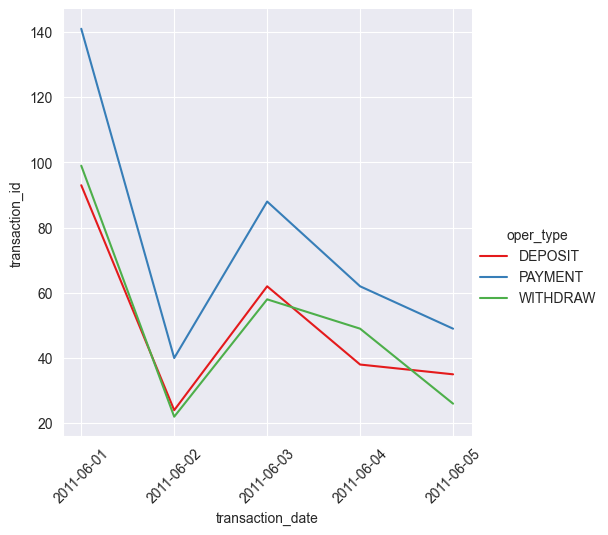

In [58]:
sns.set_style("darkgrid")
plt = sns.relplot(data = df_group_1, x='transaction_date', y='transaction_id', hue="oper_type", kind='line', palette="Set1", legend=True)
plt.set_xticklabels(rotation=45, step=2)

In [54]:
# строим барплот

df_group_2 = df_result.groupby(["transaction_date", "oper_type"]).client_id.nunique().reset_index()

df_group_2

,transaction_date,oper_type,client_id
0,2011-06-01,DEPOSIT,28
1,2011-06-01,PAYMENT,38
2,2011-06-01,WITHDRAW,34
3,2011-06-02,DEPOSIT,14
4,2011-06-02,PAYMENT,21
5,2011-06-02,WITHDRAW,17
6,2011-06-03,DEPOSIT,28
7,2011-06-03,PAYMENT,34
8,2011-06-03,WITHDRAW,31
9,2011-06-04,DEPOSIT,24


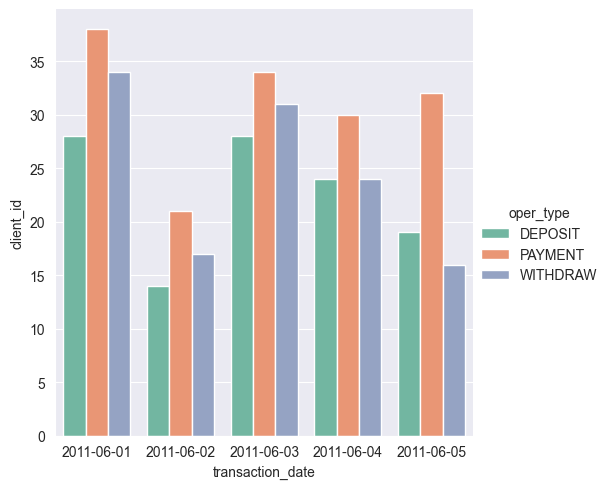

In [56]:
sns.catplot(data = df_group_2, x='transaction_date', y='client_id', hue="oper_type", kind='bar', palette="Set2", legend=True)
plt.set_xticklabels(rotation=45, step=2)

---------------------------------------------------------------------------------------

## Requests

Библиотека Requests для Python позволяет работать с HTTP-запросами любого уровня сложности, используя простой синтаксис.  
Это помогает не тратить время на написание кода, а быстро взаимодействовать с серверами.

In [ ]:
!pip install requests

С помощью модуля requests мы можем обратиться к какому - либо web-ресурсу.  
Hапример к Google!

In [ ]:
import requests
response = requests.get("https://google.com") # такая страница действительно есть!
print(response)

In [ ]:
response = requests.get("https://google.com/123") # а вот такой страницы нет!
print(response)

Коды ошибок (наиболее популярные):  
4* - ошибки клиента, например:
* 400 - ошибка в запросе (Bad Request)
* 401 - требуется авторизация (Unauthorized)
* 404 - страница не найдена (Not Found)
* и тд.   

5* - ошибка сервера, например:
* 500 - внутренняя ошибка сервера (Internal Server Error)
* 502 - плохой, ошибочный шлюз - что то с сеткой (Bad Gateway)
* 504 - шлюз не отвечает - падение по таймауту (Gateway Timeout)
* и тд. 

In [ ]:
response = requests.get("https://google.com/123")
if response:
    print("Success!")
else:
    raise Exception(f"Non-success status code: {response.status_code}")

Как можно обрабатывать запросы:

In [ ]:
import requests
from requests.exceptions import HTTPError

URLS = ["https://google.com", "https://google.com/123"]

for url in URLS:
    try:
        response = requests.get(url)
        response.raise_for_status() # запускает исключение в случае получения ошибки в диапазоне 400-600
    except HTTPError as http_err:
        print(f"HTTP error occurred: {http_err}")
    except Exception as err:
        print(f"Other error occurred: {err}")
    else:
        print("Success!")

Однако, запрашивать просто веб страницы - не особенно интересно.  
На них содержится html контент, который в целом не предназначен для программной обработки:

In [ ]:
response = requests.get("https://google.com/")
print(response.content)
print(response.text)

Гораздо интереснее становится, когда в web публикуют контент НЕ для отображения на веб-странице в браузере конечного пользователя, а для прямой интеграции с кодом.

Речь про API (application programming interface) - механизм, посредством которого приложения могут общаться между собой в сети.

In [ ]:
response = requests.get("https://api.github.com/")
print(response.content)

print(type(response.content))

In [ ]:
response = requests.get("https://api.github.com/")
response.encoding = "utf-8" # опционально
print(response.text)

print(type(response.text))

Чаще всего API взаимодействуют с неким полуструктурируемым форматом, например XML или JSON:

In [ ]:
response = requests.get("https://api.github.com/")
response.encoding = "utf-8" # опционально

response_dict = response.json()

print(response_dict)
print(type(response_dict))

response_dict["emojis_url"]


Хорошо, с контентом все понятно. Но вообще говоря HTTP запрос состоит не только из тела запроса/ответа.

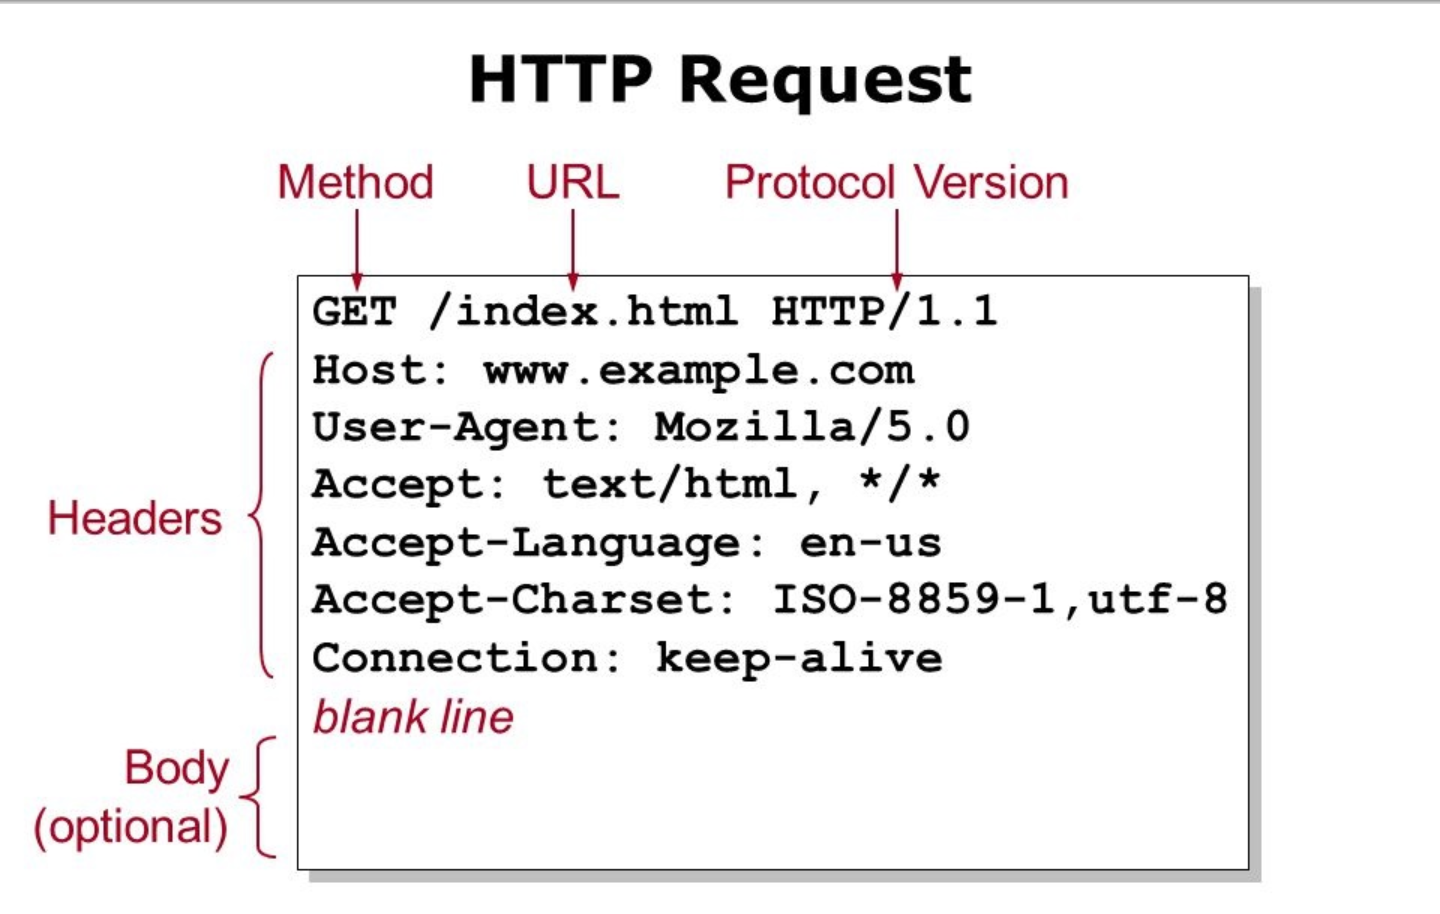

In [ ]:
response = requests.get("https://api.github.com/")

print(response.headers)

response.headers["Content-Type"]

*А где можно найти информацию о том, как общаться с API какого-либо сервиса?*   
**Ответ:** Документация!

In [ ]:
import requests

response = requests.get("https://api.github.com/search/repositories")

response.text


Обратимся к документации и посмотрим, что мы делаем не так

In [ ]:
import requests

# Search GitHub's repositories for popular Python projects
response = requests.get(
    "https://api.github.com/search/repositories",
    params={"q": "language:python", "sort": "stars", "order": "desc"},
    #params=b"q=language:python&sort=stars&order=desc",
    #[("q", "language:python"), ("sort", "stars"), ("order", "desc")],
)
print(response.text)
# Inspect some attributes of the first three repositories
json_response = response.json()
popular_repositories = json_response["items"]
for repo in popular_repositories[:3]:
    print(f"Name: {repo['name']}")
    print(f"Description: {repo['description']}")
    print(f"Stars: {repo['stargazers_count']}")
    print()

Важным аспектом работы любого API является Аутентификация. Это основа безопасности!

Здесь существует множество подходов! мы посмотрим на простейшие:
* с помощью логина и пароля

In [ ]:
response = requests.get(
    "https://httpbin.org/basic-auth/user/passwd"
)

response

In [ ]:
from requests.auth import HTTPBasicAuth
response = requests.get(
    "https://httpbin.org/basic-auth/user/passwd",
    auth=HTTPBasicAuth("user", "passwd")
)

response.text

* аутентификация с помощтю токена

In [ ]:
response = requests.get("https://api.github.com/user")

response.text

https://github.com/settings/tokens

In [ ]:
token = "REDACTED_TOKEN"
response = requests.get(
    "https://api.github.com/user",
    auth=("", token)
)

print(response)
response.text

In [ ]:
response.request.headers["Authorization"]

Важно понимать, что headers есть не только в ответе, но и в запросе!

И именно туда обычно передают всю необходимую информацию, в том числе и токены:

In [ ]:
url = "https://api.github.com/user"
token = "REDACTED_TOKEN"
headers = {
        'Authorization': f"Bearer {token}",
    }
response = requests.get(
    url=url,
    headers=headers
)

print(response)
response.text

HTTP методы:
* GET: используется для получения данных объекта
* HEAD: тоже самое что и GET, но ответ не содержит тела
* POST: используется для создания объекта
* PATCH: используется, для изменения атрибутов объекта
* PUT: используется для изменения самого объекта
* DELETE: используется для удаления объекта